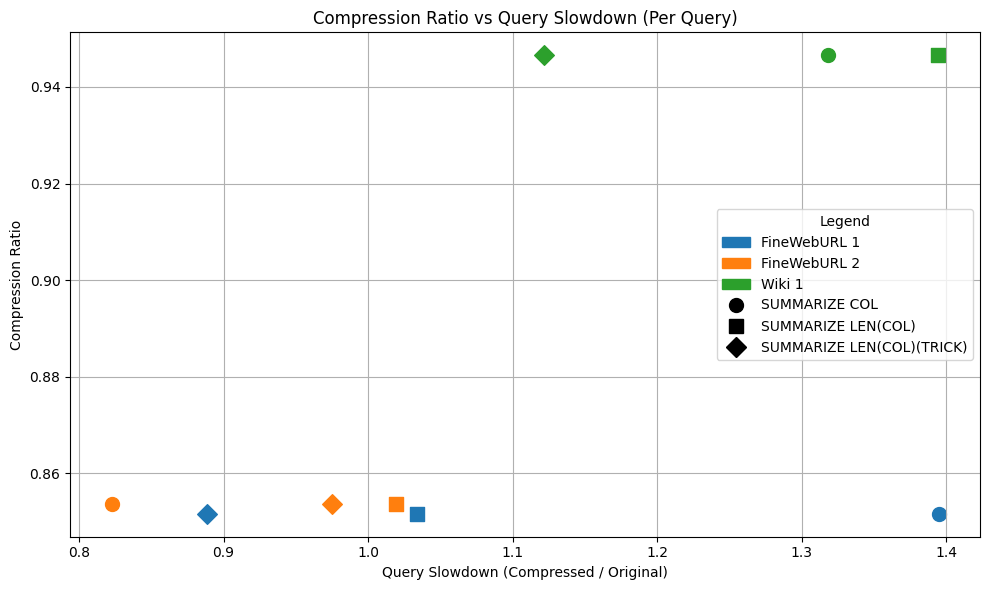

In [6]:
import matplotlib.pyplot as plt

# Example data
compression_methods = ['FineWebURL 1', 'FineWebURL 2', 'Wiki 1']
queries = ['SUMMARIZE COL', 'SUMMARIZE LEN(COL)', 'SUMMARIZE LEN(COL)(TRICK)']

compression_ratios = [0.8515934362461176, 0.8536014137811012, 0.9465596917074419]
ori_query_time = {'FineWebURL 1': [0.3443, 0.7033, 0.7033],
              'FineWebURL 2': [0.7744, 0.7572, 0.7572],
              'Wiki 1': [0.0314, 0.0312, 0.0312]}

com_query_time = {'FineWebURL 1': [0.4802, 0.7270, 0.6249],
              'FineWebURL 2': [0.6369, 0.7720, 0.7383],
              'Wiki 1': [0.0414, 0.0435, 0.0350]}


import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# Define colors per method
method_colors = {
    'FineWebURL 1': 'tab:blue',
    'FineWebURL 2': 'tab:orange',
    'Wiki 1': 'tab:green'
}

# Define marker shapes per query
query_markers = {
    0: 'o',  # Q1
    1: 's',  # Q2
    2: 'D'   # Q3
}

# Plotting
plt.figure(figsize=(10, 6))
for method_idx, method in enumerate(compression_methods):
    ratio = compression_ratios[method_idx]
    ori_times = ori_query_time[method]
    com_times = com_query_time[method]
    for query_idx in range(len(ori_times)):
        slowdown = com_times[query_idx] / ori_times[query_idx]
        plt.scatter(slowdown, ratio,
                    color=method_colors[method],
                    marker=query_markers[query_idx],
                    s=100)

# Create legend handles
method_handles = [mpatches.Patch(color=color, label=method) for method, color in method_colors.items()]
query_handles = [mlines.Line2D([], [], color='black', marker=marker, linestyle='None', markersize=10,
                               label=f'{queries[idx]}') for idx, marker in query_markers.items()]

# Add legends
plt.legend(handles=method_handles + query_handles, title="Legend", loc='right')

plt.xlabel('Query Slowdown (Compressed / Original)')
plt.ylabel('Compression Ratio')
plt.title('Compression Ratio vs Query Slowdown (Per Query)')
plt.grid(True)
plt.tight_layout()
plt.show()
